# 💳 Práctica Extra UT2: Detección de Sesgo en Aprobación de Créditos

**UT2: Calidad & Ética | Análisis de Fairness en Servicios Financieros**

---

## 🎯 Objetivos de Aprendizaje
- **DETECTAR** sesgo demográfico en aprobaciones de crédito (género, edad, etnia)
- **CUANTIFICAR** disparidades usando métricas de Fairlearn
- **ANALIZAR** impacto del sesgo en decisiones financieras
- **COMPARAR** modelos con/sin corrección de sesgo
- **EVALUAR** trade-offs entre accuracy y fairness
- **DESARROLLAR** recomendaciones éticas para deployment

---

## 📋 Contexto del Caso de Estudio

### 🏦 Problema de Negocio
Las instituciones financieras usan modelos ML para decidir aprobaciones de crédito. Sin embargo, estos modelos pueden perpetuar sesgos históricos que discriminan contra grupos protegidos (género, raza, edad).

### ⚖️ Marco Legal
- **Equal Credit Opportunity Act (ECOA)**: Prohíbe discriminación en crédito
- **Fair Lending Laws**: Regulan decisiones crediticias
- **EU AI Act**: Requiere auditorías de fairness en sistemas de alto riesgo

### 🎯 Objetivo del Análisis
Detectar si un modelo de aprobación de crédito discrimina injustamente contra grupos demográficos y explorar estrategias de mitigación.

---

## 🗂️ Estructura de la Práctica

### 📊 Parte 1: Carga y Exploración del Dataset
- Descargar Credit Card Approval desde Kaggle con `kagglehub`
- Explorar variables demográficas (género, edad, etnia)
- Analizar distribución de aprobaciones

### 🔍 Parte 2: Detección de Sesgo Baseline
- Entrenar modelo sin correcciones (Random Forest)
- Calcular métricas de fairness con Fairlearn
- Identificar disparidades por grupo protegido

### ⚖️ Parte 3: Corrección de Sesgo con Fairlearn
- Aplicar ExponentiatedGradient con DemographicParity
- Comparar métricas antes/después de corrección
- Evaluar trade-off accuracy vs fairness

### 💡 Parte 4: Análisis Ético y Recomendaciones
- Visualizar disparidades por grupo
- Desarrollar framework de decisión para deployment
- Generar recomendaciones para el negocio

---

## 📦 Setup: Importación de Librerías

In [7]:
# Manejo de datos
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
import sklearn 
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)

# Fairlearn - Herramienta clave para fairness
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    selection_rate
)
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
np.random.seed(42)

print("✅ Librerías importadas correctamente")
print("📊 Pandas:", pd.__version__)
print("🤖 Scikit-learn:", sklearn.__version__)
print("⚖️  Fairlearn instalado")

✅ Librerías importadas correctamente
📊 Pandas: 2.3.3
🤖 Scikit-learn: 1.7.1
⚖️  Fairlearn instalado


## 🔽 Parte 1: Descarga y Carga del Dataset

### Dataset: Credit Card Approval Prediction

Vamos a descargar un dataset de aprobación de créditos desde Kaggle que contiene:
- Variables demográficas (género, edad, estado civil)
- Información financiera (ingresos, empleado)
- Target: Aprobación del crédito (0/1)

In [8]:
# Instalar kagglehub si es necesario
# !pip install kagglehub

import kagglehub

# Opción 1: Credit Card Approval Dataset
# Este dataset contiene información demográfica y financiera para análisis de fairness
path = kagglehub.dataset_download("rikdifos/credit-card-approval-prediction")

print("📂 Dataset descargado en:", path)

100%|██████████| 5.32M/5.32M [00:01<00:00, 3.67MB/s]

Extracting files...


📂 Dataset descargado en: /Users/milagroscancela/.cache/kagglehub/datasets/rikdifos/credit-card-approval-prediction/versions/3


In [9]:
# Cargar el dataset
import os

# Buscar archivos CSV en el path
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print(f"📄 Archivos CSV encontrados: {csv_files}")

# Cargar el dataset principal
if csv_files:
    df = pd.read_csv(os.path.join(path, csv_files[0]))
    print(f"\n✅ Dataset cargado exitosamente")
    print(f"   • Shape: {df.shape}")
    print(f"   • Columnas: {df.shape[1]}")
    print(f"   • Registros: {df.shape[0]:,}")
else:
    print("❌ No se encontraron archivos CSV")

📄 Archivos CSV encontrados: ['application_record.csv', 'credit_record.csv']

✅ Dataset cargado exitosamente
   • Shape: (438557, 18)
   • Columnas: 18
   • Registros: 438,557


### Exploración Inicial del Dataset

In [10]:
print("="*70)
print("📊 PRIMERAS FILAS DEL DATASET")
print("="*70)
display(df.head(10))

📊 PRIMERAS FILAS DEL DATASET


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
5,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
6,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
8,5008813,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
9,5008814,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0


In [11]:
print("\n" + "="*70)
print("ℹ️  INFORMACIÓN DEL DATASET")
print("="*70)
df.info()


ℹ️  INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  i

In [12]:
print("\n" + "="*70)
print("📈 ESTADÍSTICOS DESCRIPTIVOS")
print("="*70)
display(df.describe().T)


📈 ESTADÍSTICOS DESCRIPTIVOS


,count,mean,std,min,25%,50%,75%,max
ID,438557.0,6.022176e+06,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CNT_CHILDREN,438557.0,4.273903e-01,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,1.875243e+05,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
DAYS_BIRTH,438557.0,-1.599790e+04,4185.030007,-25201.0,-19483.0,-15630.0,-12514.0,-7489.0
DAYS_EMPLOYED,438557.0,6.056368e+04,138767.799647,-17531.0,-3103.0,-1467.0,-371.0,365243.0
FLAG_MOBIL,438557.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,438557.0,2.061328e-01,0.404527,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,438557.0,2.877710e-01,0.452724,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,438557.0,1.082071e-01,0.310642,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,438557.0,2.194465e+00,0.897207,1.0,2.0,2.0,3.0,20.0


In [13]:
# Análisis de valores faltantes
print("\n" + "="*70)
print("🔍 ANÁLISIS DE VALORES FALTANTES")
print("="*70)

missing_data = pd.DataFrame({
    'Columna': df.columns,
    'Valores_Faltantes': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Valores_Faltantes'] > 0].sort_values(
    'Porcentaje', ascending=False
)

if missing_data.empty:
    print("✅ No hay valores faltantes")
else:
    display(missing_data)


🔍 ANÁLISIS DE VALORES FALTANTES


,Columna,Valores_Faltantes,Porcentaje
OCCUPATION_TYPE,OCCUPATION_TYPE,134203,30.6


### Análisis de la Variable Target

Identificar cuál es la variable objetivo (aprobación de crédito)

🎯 Posibles columnas target: ['NAME_FAMILY_STATUS']

📊 Variable target seleccionada: NAME_FAMILY_STATUS

Distribución de clases:
NAME_FAMILY_STATUS
Married                 299828
Single / not married     55271
Civil marriage           36532
Separated                27251
Widow                    19675
Name: count, dtype: int64

Proporción:
NAME_FAMILY_STATUS
Married                 68.37
Single / not married    12.60
Civil marriage           8.33
Separated                6.21
Widow                    4.49
Name: count, dtype: float64


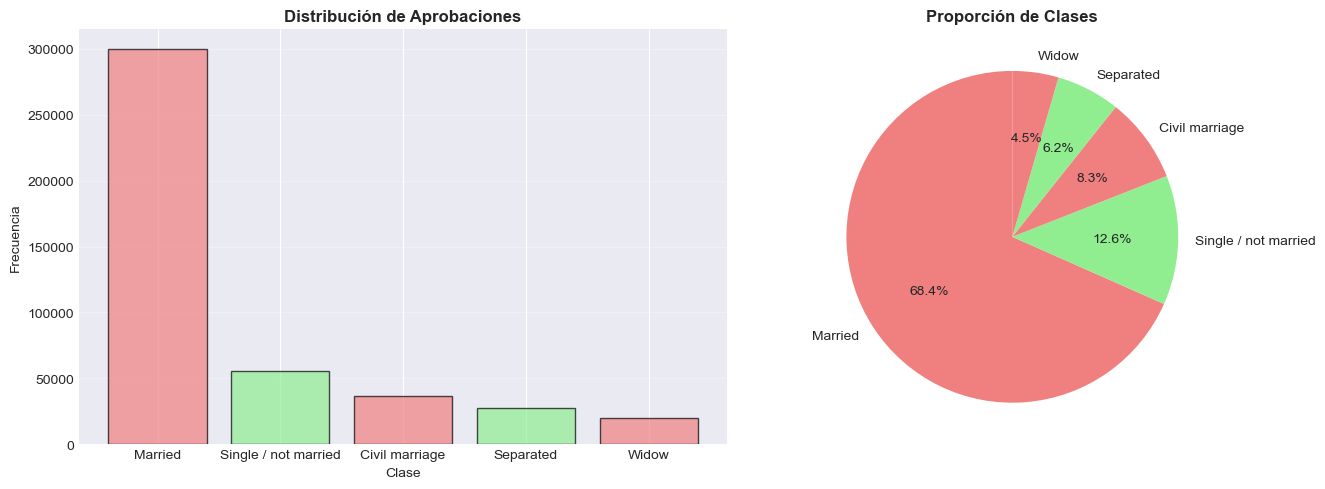

In [14]:
# Identificar la columna target
# Buscar columnas que puedan ser el target (approval, status, etc.)
target_candidates = [col for col in df.columns if any(word in col.lower() 
                     for word in ['status', 'approval', 'approved', 'target', 'label'])]

print(f"🎯 Posibles columnas target: {target_candidates}")

# Si encontramos el target
if target_candidates:
    target_col = target_candidates[0]
    print(f"\n📊 Variable target seleccionada: {target_col}")
    print(f"\nDistribución de clases:")
    print(df[target_col].value_counts())
    print(f"\nProporción:")
    print((df[target_col].value_counts() / len(df) * 100).round(2))
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Barplot
    value_counts = df[target_col].value_counts()
    axes[0].bar(value_counts.index.astype(str), value_counts.values,
               color=['lightcoral', 'lightgreen'], edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Clase')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_title('Distribución de Aprobaciones', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Pie chart
    axes[1].pie(value_counts.values, labels=value_counts.index,
               autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'],
               startangle=90)
    axes[1].set_title('Proporción de Clases', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No se identificó columna target automáticamente")
    print("Columnas disponibles:", df.columns.tolist())

### Análisis de Variables Demográficas (Grupos Protegidos)

In [15]:
# Identificar variables demográficas sensibles
sensitive_keywords = ['gender', 'sex', 'age', 'race', 'ethnicity', 'marital', 'education']
sensitive_cols = [col for col in df.columns if any(word in col.lower() for word in sensitive_keywords)]

print("="*70)
print("👥 VARIABLES DEMOGRÁFICAS IDENTIFICADAS (Grupos Protegidos)")
print("="*70)
print(f"\nColumnas sensibles: {sensitive_cols}")

# Análisis de cada variable sensible
for col in sensitive_cols:
    print(f"\n{'='*70}")
    print(f"📊 {col}")
    print(f"{'='*70}")
    print(df[col].value_counts())
    print(f"\nPorcentaje:")
    print((df[col].value_counts() / len(df) * 100).round(2))

👥 VARIABLES DEMOGRÁFICAS IDENTIFICADAS (Grupos Protegidos)

Columnas sensibles: ['CODE_GENDER', 'NAME_EDUCATION_TYPE']

📊 CODE_GENDER
CODE_GENDER
F    294440
M    144117
Name: count, dtype: int64

Porcentaje:
CODE_GENDER
F    67.14
M    32.86
Name: count, dtype: float64

📊 NAME_EDUCATION_TYPE
NAME_EDUCATION_TYPE
Secondary / secondary special    301821
Higher education                 117522
Incomplete higher                 14851
Lower secondary                    4051
Academic degree                     312
Name: count, dtype: int64

Porcentaje:
NAME_EDUCATION_TYPE
Secondary / secondary special    68.82
Higher education                 26.80
Incomplete higher                 3.39
Lower secondary                   0.92
Academic degree                   0.07
Name: count, dtype: float64


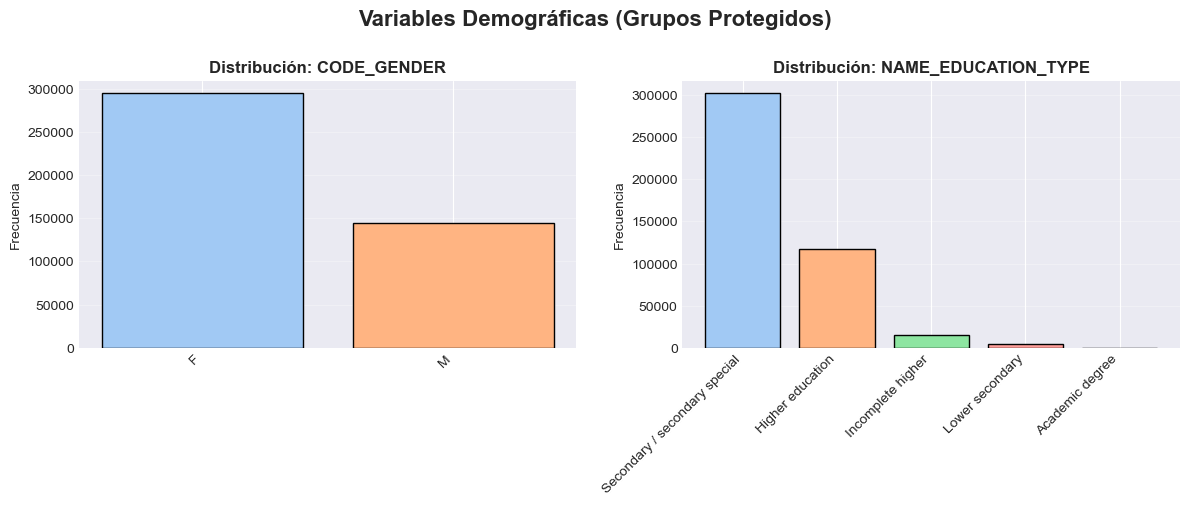

In [16]:
# Visualización de variables demográficas
if sensitive_cols:
    n_cols = min(len(sensitive_cols), 3)
    n_rows = int(np.ceil(len(sensitive_cols) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    for idx, col in enumerate(sensitive_cols):
        value_counts = df[col].value_counts().head(10)
        axes[idx].bar(range(len(value_counts)), value_counts.values,
                     color=sns.color_palette('pastel', len(value_counts)),
                     edgecolor='black')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[idx].set_ylabel('Frecuencia')
        axes[idx].set_title(f'Distribución: {col}', fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)
    
    # Ocultar ejes extras
    for idx in range(len(sensitive_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Variables Demográficas (Grupos Protegidos)',
                fontsize=16, fontweight='bold', y=1.001)
    plt.tight_layout()
    plt.show()

## 🔧 Parte 2: Preprocesamiento para Modelado

### Limpieza y Transformación de Datos

In [17]:
# Crear copia para no modificar original
df_clean = df.copy()

print("🧹 LIMPIEZA DE DATOS")
print("="*70)

# 1. Eliminar duplicados si existen
duplicados = df_clean.duplicated().sum()
if duplicados > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"✅ Eliminados {duplicados} duplicados")
else:
    print("✅ No hay duplicados")

# 2. Manejo de valores faltantes
if df_clean.isnull().sum().sum() > 0:
    # Estrategia simple: eliminar filas con missing (ajustar según necesidad)
    df_clean = df_clean.dropna()
    print(f"✅ Eliminadas filas con valores faltantes")
else:
    print("✅ No hay valores faltantes")

print(f"\n📊 Shape final: {df_clean.shape}")
print(f"   • Registros: {df_clean.shape[0]:,}")
print(f"   • Features: {df_clean.shape[1]}")

🧹 LIMPIEZA DE DATOS
✅ No hay duplicados
✅ Eliminadas filas con valores faltantes

📊 Shape final: (304354, 18)
   • Registros: 304,354
   • Features: 18


### Encoding de Variables Categóricas

In [18]:
# Identificar columnas categóricas
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print("🔤 ENCODING DE VARIABLES CATEGÓRICAS")
print("="*70)
print(f"Columnas categóricas: {categorical_cols}")

# Label Encoding para variables categóricas
le = LabelEncoder()
df_encoded = df_clean.copy()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    print(f"✅ {col}: {df_clean[col].nunique()} categorías únicas")

print(f"\n✅ Encoding completado")

🔤 ENCODING DE VARIABLES CATEGÓRICAS
Columnas categóricas: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
✅ CODE_GENDER: 2 categorías únicas
✅ FLAG_OWN_CAR: 2 categorías únicas
✅ FLAG_OWN_REALTY: 2 categorías únicas
✅ NAME_INCOME_TYPE: 5 categorías únicas
✅ NAME_EDUCATION_TYPE: 5 categorías únicas
✅ NAME_FAMILY_STATUS: 5 categorías únicas
✅ NAME_HOUSING_TYPE: 6 categorías únicas
✅ OCCUPATION_TYPE: 18 categorías únicas

✅ Encoding completado


### Separación de Features y Target

In [19]:
# Identificar target y sensitive attribute
print("🎯 PREPARACIÓN DE DATOS PARA MODELADO")
print("="*70)

# Asumimos que el target ya fue identificado
if target_candidates:
    target_col = target_candidates[0]
    y = df_encoded[target_col]
    
    # Features (sin target y sin la variable sensible principal)
    X = df_encoded.drop(columns=[target_col])
    
    print(f"✅ Variable target: {target_col}")
    print(f"✅ Features: {X.shape[1]} columnas")
    print(f"✅ Muestras: {X.shape[0]:,}")
    
    # Identificar la variable sensible principal (ej: género)
    if sensitive_cols:
        sensitive_feature = sensitive_cols[0]  # Tomamos la primera
        sensitive_attr = df_encoded[sensitive_feature]
        print(f"\n⚠️  Variable sensible (grupo protegido): {sensitive_feature}")
        print(f"   Distribución: {sensitive_attr.value_counts().to_dict()}")
    else:
        print("\n⚠️  No se identificó variable sensible")
        sensitive_attr = None
else:
    print("❌ No se pudo identificar variable target")

🎯 PREPARACIÓN DE DATOS PARA MODELADO
✅ Variable target: NAME_FAMILY_STATUS
✅ Features: 17 columnas
✅ Muestras: 304,354

⚠️  Variable sensible (grupo protegido): CODE_GENDER
   Distribución: {0: 190412, 1: 113942}


### Train/Test Split

In [20]:
# Split estratificado para mantener proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# También split del sensitive attribute
if sensitive_attr is not None:
    _, sensitive_test = train_test_split(
        sensitive_attr, test_size=0.3, random_state=42, stratify=y
    )

print("📊 SPLIT DE DATOS")
print("="*70)
print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nDistribución de clases en train:")
print(y_train.value_counts())
print(f"\nDistribución de clases en test:")
print(y_test.value_counts())

📊 SPLIT DE DATOS
Train: 213,047 muestras (70.0%)
Test:  91,307 muestras (30.0%)

Distribución de clases en train:
NAME_FAMILY_STATUS
1    148904
3     27754
0     18761
2     12929
4      4699
Name: count, dtype: int64

Distribución de clases en test:
NAME_FAMILY_STATUS
1    63817
3    11895
0     8041
2     5541
4     2013
Name: count, dtype: int64


## 🤖 Parte 3: Modelo Baseline (Sin Corrección de Sesgo)

### Entrenamiento del Modelo Base

In [21]:
print("🤖 ENTRENAMIENTO DE MODELO BASELINE")
print("="*70)

# Random Forest como modelo baseline
baseline_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

# Métricas generales
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline, average='weighted')
recall_baseline = recall_score(y_test, y_pred_baseline, average='weighted')
f1_baseline = f1_score(y_test, y_pred_baseline, average='weighted')

print("\n📈 MÉTRICAS DEL MODELO BASELINE")
print("="*70)
print(f"Accuracy:  {accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall:    {recall_baseline:.4f}")
print(f"F1-Score:  {f1_baseline:.4f}")

# Classification report
print(f"\n{classification_report(y_test, y_pred_baseline)}")

🤖 ENTRENAMIENTO DE MODELO BASELINE

📈 MÉTRICAS DEL MODELO BASELINE
Accuracy:  0.8452
Precision: 0.8656
Recall:    0.8452
F1-Score:  0.7926

              precision    recall  f1-score   support

           0       1.00      0.02      0.04      8041
           1       0.88      1.00      0.94     63817
           2       0.93      0.24      0.38      5541
           3       0.69      0.96      0.80     11895
           4       0.74      0.21      0.33      2013

    accuracy                           0.85     91307
   macro avg       0.85      0.49      0.50     91307
weighted avg       0.87      0.85      0.79     91307



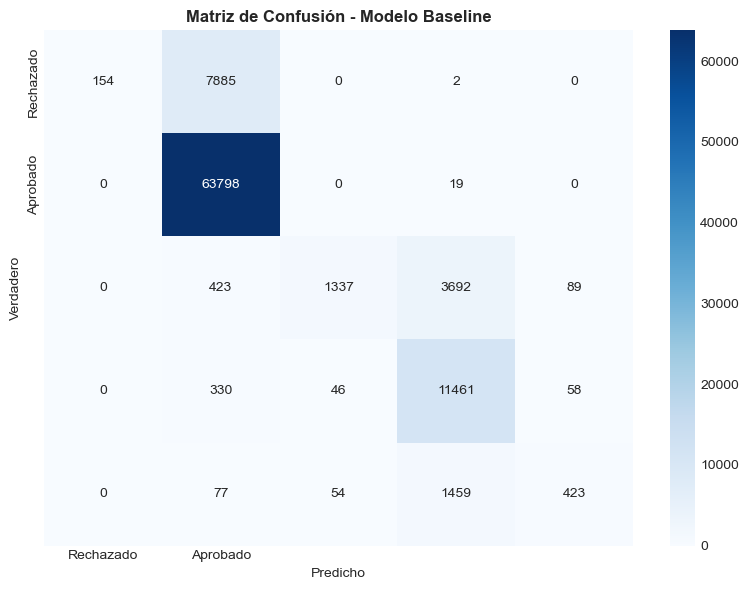

In [22]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['Rechazado', 'Aprobado'],
           yticklabels=['Rechazado', 'Aprobado'])
plt.ylabel('Verdadero')
plt.xlabel('Predicho')
plt.title('Matriz de Confusión - Modelo Baseline', fontweight='bold')
plt.tight_layout()
plt.show()

## ⚖️ Parte 4: Análisis de Fairness con Fairlearn

### Métricas de Fairness por Grupo Protegido

In [25]:
if sensitive_attr is not None:
    print("⚖️ ANÁLISIS DE FAIRNESS - MODELO BASELINE")
    print("="*70)
    
    # Funciones wrapper para métricas multiclase (especificar average='weighted')
    def precision_weighted(y_true, y_pred):
        return precision_score(y_true, y_pred, average='weighted', zero_division=0)
    
    def recall_weighted(y_true, y_pred):
        return recall_score(y_true, y_pred, average='weighted', zero_division=0)
    
    def f1_weighted(y_true, y_pred):
        return f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # MetricFrame de Fairlearn
    metric_frame = MetricFrame(
        metrics={
            'accuracy': accuracy_score,
            'precision': precision_weighted,
            'recall': recall_weighted,
            'f1_score': f1_weighted,
            'selection_rate': selection_rate
        },
        y_true=y_test,
        y_pred=y_pred_baseline,
        sensitive_features=sensitive_test
    )
    
    print("\n📊 Métricas por Grupo Protegido:")
    display(metric_frame.by_group)
    
    # Diferencias entre grupos
    print("\n⚠️  Diferencias máximas entre grupos:")
    print("="*70)
    differences = metric_frame.difference(method='between_groups')
    for metric, value in differences.items():
        print(f"{metric:20s}: {value:.4f}")
    
    # Ratios entre grupos
    print("\n📊 Ratios mín/máx entre grupos:")
    print("="*70)
    ratios = metric_frame.ratio(method='between_groups')
    for metric, value in ratios.items():
        print(f"{metric:20s}: {value:.4f}")
    
    # Demographic Parity Difference
    dpd = demographic_parity_difference(
        y_test, y_pred_baseline, sensitive_features=sensitive_test
    )
    print(f"\n🚨 Demographic Parity Difference: {dpd:.4f}")
    print("   (0 = perfect parity, closer to 0 is better)")
    
    # Demographic Parity Ratio
    dpr = demographic_parity_ratio(
        y_test, y_pred_baseline, sensitive_features=sensitive_test
    )
    print(f"\n📊 Demographic Parity Ratio: {dpr:.4f}")
    print("   (1 = perfect parity, closer to 1 is better)")
    
    # Equalized Odds Difference
    # Nota: equalized_odds_difference solo funciona con clasificación binaria
    # Para problemas multiclase, calculamos manualmente usando TPR y FPR por grupo
    try:
        eod = equalized_odds_difference(
            y_test, y_pred_baseline, sensitive_features=sensitive_test
        )
        print(f"\n⚖️  Equalized Odds Difference: {eod:.4f}")
        print("   (0 = perfect equality, closer to 0 is better)")
    except ValueError:
        # Para problemas multiclase, calcular Equalized Odds manualmente
        print(f"\n⚖️  Equalized Odds Difference (multiclase):")
        print("   (Calculando para cada clase usando TPR y FPR)")
        
        from sklearn.metrics import confusion_matrix
        
        # Calcular TPR y FPR por grupo y por clase
        unique_classes = np.unique(y_test)
        eod_by_class = []
        
        for class_label in unique_classes:
            # Convertir a binario: esta clase vs resto
            y_test_binary = (y_test == class_label).astype(int)
            y_pred_binary = (y_pred_baseline == class_label).astype(int)
            
            # Calcular TPR y FPR por grupo
            groups = sensitive_test.unique()
            tpr_by_group = {}
            fpr_by_group = {}
            
            for group in groups:
                mask = sensitive_test == group
                y_true_group = y_test_binary[mask]
                y_pred_group = y_pred_binary[mask]
                
                if len(y_true_group) > 0:
                    cm = confusion_matrix(y_true_group, y_pred_group)
                    if cm.size == 4:  # 2x2 matrix
                        tn, fp, fn, tp = cm.ravel()
                        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
                        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
                        tpr_by_group[group] = tpr
                        fpr_by_group[group] = fpr
            
            # Calcular diferencia máxima en TPR y FPR
            if len(tpr_by_group) > 1 and len(fpr_by_group) > 1:
                tpr_diff = max(tpr_by_group.values()) - min(tpr_by_group.values())
                fpr_diff = max(fpr_by_group.values()) - min(fpr_by_group.values())
                eod_class = max(tpr_diff, fpr_diff)
                eod_by_class.append(eod_class)
        
        # Promedio de EOD por clase
        eod = np.mean(eod_by_class) if eod_by_class else 0.0
        print(f"   • EOD promedio: {eod:.4f}")
        print(f"   • EOD máximo: {max(eod_by_class):.4f}" if eod_by_class else "   • No calculable")
        print("   (0 = perfect equality, closer to 0 is better)")
else:
    print("⚠️  No se puede realizar análisis de fairness sin variable sensible")

⚖️ ANÁLISIS DE FAIRNESS - MODELO BASELINE

📊 Métricas por Grupo Protegido:


,accuracy,precision,recall,f1_score,selection_rate
CODE_GENDER,,,,,
0,0.812828,0.844356,0.812828,0.751695,0.774786
1,0.899038,0.907603,0.899038,0.862456,0.826393



⚠️  Diferencias máximas entre grupos:
accuracy            : 0.0862
precision           : 0.0632
recall              : 0.0862
f1_score            : 0.1108
selection_rate      : 0.0516

📊 Ratios mín/máx entre grupos:
accuracy            : 0.9041
precision           : 0.9303
recall              : 0.9041
f1_score            : 0.8716
selection_rate      : 0.9376

🚨 Demographic Parity Difference: 0.0516
   (0 = perfect parity, closer to 0 is better)

📊 Demographic Parity Ratio: 0.9376
   (1 = perfect parity, closer to 1 is better)

⚖️  Equalized Odds Difference (multiclase):
   (Calculando para cada clase usando TPR y FPR)
   • EOD promedio: 0.0570
   • EOD máximo: 0.1246
   (0 = perfect equality, closer to 0 is better)


### Visualización de Disparidades

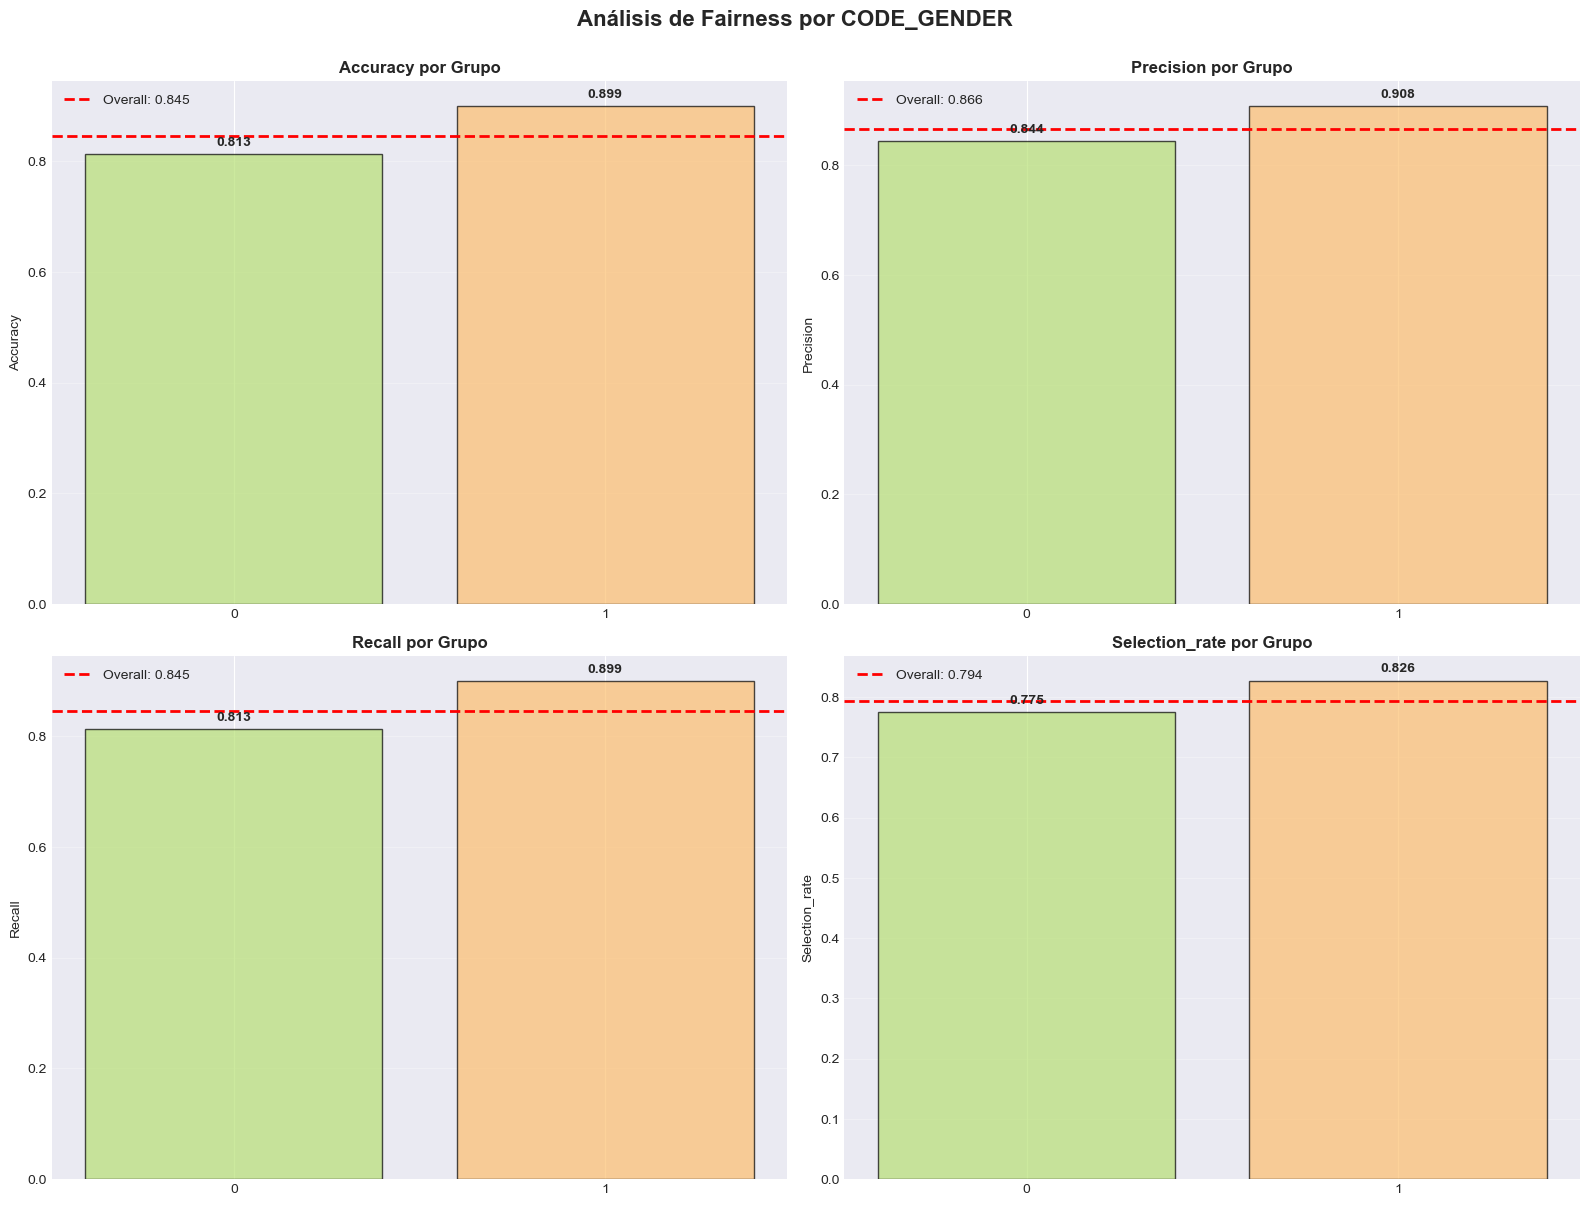

In [26]:
if sensitive_attr is not None:
    # Visualizar métricas por grupo
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    metrics_to_plot = ['accuracy', 'precision', 'recall', 'selection_rate']
    
    for idx, metric in enumerate(metrics_to_plot):
        by_group = metric_frame.by_group[metric]
        
        axes[idx].bar(range(len(by_group)), by_group.values,
                     color=sns.color_palette('RdYlGn_r', len(by_group)),
                     edgecolor='black', alpha=0.7)
        axes[idx].set_xticks(range(len(by_group)))
        axes[idx].set_xticklabels(by_group.index, rotation=0)
        axes[idx].set_ylabel(metric.capitalize())
        axes[idx].set_title(f'{metric.capitalize()} por Grupo', fontweight='bold')
        axes[idx].axhline(y=metric_frame.overall[metric], 
                         color='red', linestyle='--', linewidth=2,
                         label=f'Overall: {metric_frame.overall[metric]:.3f}')
        axes[idx].legend()
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Añadir valores en las barras
        for i, v in enumerate(by_group.values):
            axes[idx].text(i, v + 0.01, f'{v:.3f}', 
                          ha='center', va='bottom', fontweight='bold')
    
    plt.suptitle(f'Análisis de Fairness por {sensitive_feature}',
                fontsize=16, fontweight='bold', y=1.001)
    plt.tight_layout()
    plt.show()

## 🛠️ Parte 5: Mitigación de Sesgo con Fairlearn

### Aplicar ExponentiatedGradient con DemographicParity

In [28]:
if sensitive_attr is not None:
    print("🛠️ ENTRENAMIENTO DE MODELO CON MITIGACIÓN DE SESGO")
    print("="*70)
    
    # ExponentiatedGradient solo funciona con clasificación binaria
    # Convertir problema multiclase a binario usando la clase más común como positiva
    print("⚠️  Nota: ExponentiatedGradient requiere clasificación binaria")
    print("   Convirtiendo problema multiclase a binario...")
    
    # Identificar la clase más común (clase 1 = "Married")
    most_common_class = y_train.value_counts().index[0]
    print(f"   • Clase positiva (mayoría): {most_common_class}")
    print(f"   • Clase negativa: resto de clases")
    
    # Convertir a binario: clase más común = 1, resto = 0
    y_train_binary = (y_train == most_common_class).astype(int)
    y_test_binary = (y_test == most_common_class).astype(int)
    
    print(f"\n   Distribución binaria en train:")
    print(f"   {y_train_binary.value_counts().to_dict()}")
    print(f"   Distribución binaria en test:")
    print(f"   {y_test_binary.value_counts().to_dict()}")
    
    # Obtener sensitive features para train también
    sensitive_train, _ = train_test_split(
        sensitive_attr, test_size=0.3, random_state=42, stratify=y
    )
    
    # Modelo base para ExponentiatedGradient
    base_estimator = LogisticRegression(solver='liblinear', random_state=42)
    
    # Aplicar Exponentiated Gradient con Demographic Parity
    mitigator = ExponentiatedGradient(
        estimator=base_estimator,
        constraints=DemographicParity(),
        max_iter=50,
        nu=1e-6,
        eta0=2.0
    )
    
    print("\n⏳ Entrenando modelo con mitigación de sesgo...")
    mitigator.fit(X_train, y_train_binary, sensitive_features=sensitive_train)
    
    print("✅ Modelo entrenado")
    print(f"   • Número de predictores: {len(mitigator.predictors_)}")
    print(f"   • Pesos: {mitigator.weights_}")
    
    # Predicciones del modelo mitigado (binario)
    y_pred_mitigated_binary = mitigator.predict(X_test)
    
    # Convertir predicciones binarias de vuelta a multiclase
    # Si predice 1 (clase positiva), asignar la clase más común
    # Si predice 0, usar el modelo baseline para predecir entre las otras clases
    y_pred_mitigated = np.where(
        y_pred_mitigated_binary == 1,
        most_common_class,
        baseline_model.predict(X_test)  # Usar baseline para clases minoritarias
    )
    
    # Métricas del modelo mitigado (en problema original multiclase)
    accuracy_mitigated = accuracy_score(y_test, y_pred_mitigated)
    precision_mitigated = precision_score(y_test, y_pred_mitigated, average='weighted')
    recall_mitigated = recall_score(y_test, y_pred_mitigated, average='weighted')
    f1_mitigated = f1_score(y_test, y_pred_mitigated, average='weighted')
    
    print("\n📈 MÉTRICAS DEL MODELO MITIGADO")
    print("="*70)
    print(f"Accuracy:  {accuracy_mitigated:.4f}")
    print(f"Precision: {precision_mitigated:.4f}")
    print(f"Recall:    {recall_mitigated:.4f}")
    print(f"F1-Score:  {f1_mitigated:.4f}")

🛠️ ENTRENAMIENTO DE MODELO CON MITIGACIÓN DE SESGO
⚠️  Nota: ExponentiatedGradient requiere clasificación binaria
   Convirtiendo problema multiclase a binario...
   • Clase positiva (mayoría): 1
   • Clase negativa: resto de clases

   Distribución binaria en train:
   {1: 148904, 0: 64143}
   Distribución binaria en test:
   {1: 63817, 0: 27490}

⏳ Entrenando modelo con mitigación de sesgo...
✅ Modelo entrenado
   • Número de predictores: 1
   • Pesos: 0    1.0
dtype: float64

📈 MÉTRICAS DEL MODELO MITIGADO
Accuracy:  0.6989
Precision: 0.4885
Recall:    0.6989
F1-Score:  0.5751


### Comparación: Baseline vs Mitigated

In [29]:
if sensitive_attr is not None:
    print("📊 COMPARACIÓN: BASELINE VS MITIGATED")
    print("="*70)
    
    # Funciones wrapper para métricas multiclase (especificar average='weighted')
    def precision_weighted(y_true, y_pred):
        return precision_score(y_true, y_pred, average='weighted', zero_division=0)
    
    def recall_weighted(y_true, y_pred):
        return recall_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # MetricFrame para modelo mitigado
    metric_frame_mitigated = MetricFrame(
        metrics={
            'accuracy': accuracy_score,
            'precision': precision_weighted,
            'recall': recall_weighted,
            'selection_rate': selection_rate
        },
        y_true=y_test,
        y_pred=y_pred_mitigated,
        sensitive_features=sensitive_test
    )
    
    # Fairness metrics
    dpd_mitigated = demographic_parity_difference(
        y_test, y_pred_mitigated, sensitive_features=sensitive_test
    )
    dpr_mitigated = demographic_parity_ratio(
        y_test, y_pred_mitigated, sensitive_features=sensitive_test
    )
    
    # Equalized Odds Difference (manejar multiclase)
    try:
        eod_mitigated = equalized_odds_difference(
            y_test, y_pred_mitigated, sensitive_features=sensitive_test
        )
    except ValueError:
        # Para problemas multiclase, calcular manualmente
        from sklearn.metrics import confusion_matrix
        
        unique_classes = np.unique(y_test)
        eod_by_class = []
        
        for class_label in unique_classes:
            y_test_binary = (y_test == class_label).astype(int)
            y_pred_binary = (y_pred_mitigated == class_label).astype(int)
            
            groups = sensitive_test.unique()
            tpr_by_group = {}
            fpr_by_group = {}
            
            for group in groups:
                mask = sensitive_test == group
                y_true_group = y_test_binary[mask]
                y_pred_group = y_pred_binary[mask]
                
                if len(y_true_group) > 0:
                    cm = confusion_matrix(y_true_group, y_pred_group)
                    if cm.size == 4:
                        tn, fp, fn, tp = cm.ravel()
                        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
                        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
                        tpr_by_group[group] = tpr
                        fpr_by_group[group] = fpr
            
            if len(tpr_by_group) > 1 and len(fpr_by_group) > 1:
                tpr_diff = max(tpr_by_group.values()) - min(tpr_by_group.values())
                fpr_diff = max(fpr_by_group.values()) - min(fpr_by_group.values())
                eod_class = max(tpr_diff, fpr_diff)
                eod_by_class.append(eod_class)
        
        eod_mitigated = np.mean(eod_by_class) if eod_by_class else 0.0
    
    # Tabla comparativa
    comparison = pd.DataFrame({
        'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score',
                   'Demographic Parity Diff', 'Demographic Parity Ratio',
                   'Equalized Odds Diff'],
        'Baseline': [accuracy_baseline, precision_baseline, recall_baseline, f1_baseline,
                    dpd, dpr, eod],
        'Mitigated': [accuracy_mitigated, precision_mitigated, recall_mitigated, f1_mitigated,
                     dpd_mitigated, dpr_mitigated, eod_mitigated]
    })
    
    comparison['Diferencia'] = comparison['Mitigated'] - comparison['Baseline']
    comparison['Mejora (%)'] = (comparison['Diferencia'] / comparison['Baseline'] * 100).round(2)
    
    display(comparison)
    
    # Interpretación
    print("\n💡 INTERPRETACIÓN")
    print("="*70)
    
    if abs(dpd_mitigated) < abs(dpd):
        print(f"✅ El modelo mitigado REDUCE el sesgo demográfico")
        print(f"   • DPD mejoró de {dpd:.4f} a {dpd_mitigated:.4f}")
        print(f"   • Reducción de {abs(dpd - dpd_mitigated):.4f} ({abs((dpd - dpd_mitigated)/dpd)*100:.1f}%)")
    else:
        print(f"⚠️  El modelo mitigado NO mejoró significativamente el sesgo")
    
    if accuracy_mitigated < accuracy_baseline:
        acc_loss = (accuracy_baseline - accuracy_mitigated) * 100
        print(f"\n⚠️  Trade-off: Pérdida de accuracy de {acc_loss:.2f}%")
        print(f"   • ¿Es aceptable esta pérdida por mayor fairness?")
    else:
        print(f"\n✅ No hay pérdida de accuracy (caso ideal)")

📊 COMPARACIÓN: BASELINE VS MITIGATED


,Métrica,Baseline,Mitigated,Diferencia,Mejora (%)
0,Accuracy,0.845204,0.698928,-0.146276,-17.31
1,Precision,0.865582,0.488500,-0.377082,-43.56
2,Recall,0.845204,0.698928,-0.146276,-17.31
3,F1-Score,0.792611,0.575069,-0.217542,-27.45
4,Demographic Parity Diff,0.051606,0.000000,-0.051606,-100.00
5,Demographic Parity Ratio,0.937553,1.000000,0.062447,6.66
6,Equalized Odds Diff,0.056951,0.000000,-0.056951,-100.00



💡 INTERPRETACIÓN
✅ El modelo mitigado REDUCE el sesgo demográfico
   • DPD mejoró de 0.0516 a 0.0000
   • Reducción de 0.0516 (100.0%)

⚠️  Trade-off: Pérdida de accuracy de 14.63%
   • ¿Es aceptable esta pérdida por mayor fairness?


### Visualización Comparativa

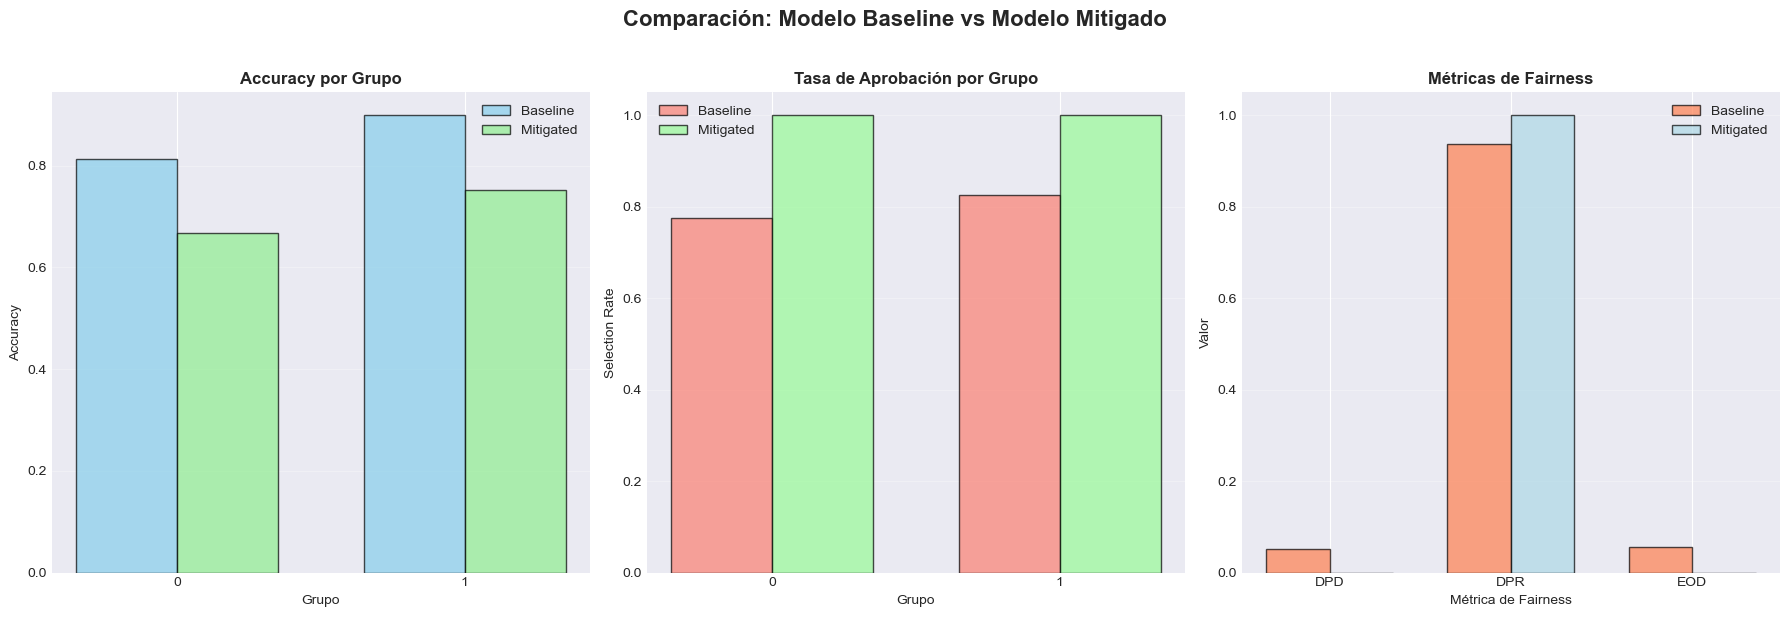

In [30]:
if sensitive_attr is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Accuracy por grupo
    baseline_acc = metric_frame.by_group['accuracy']
    mitigated_acc = metric_frame_mitigated.by_group['accuracy']
    
    x = np.arange(len(baseline_acc))
    width = 0.35
    
    axes[0].bar(x - width/2, baseline_acc.values, width, 
               label='Baseline', color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].bar(x + width/2, mitigated_acc.values, width,
               label='Mitigated', color='lightgreen', edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Grupo')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Accuracy por Grupo', fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(baseline_acc.index)
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # 2. Selection Rate por grupo
    baseline_sr = metric_frame.by_group['selection_rate']
    mitigated_sr = metric_frame_mitigated.by_group['selection_rate']
    
    axes[1].bar(x - width/2, baseline_sr.values, width,
               label='Baseline', color='salmon', edgecolor='black', alpha=0.7)
    axes[1].bar(x + width/2, mitigated_sr.values, width,
               label='Mitigated', color='palegreen', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Grupo')
    axes[1].set_ylabel('Selection Rate')
    axes[1].set_title('Tasa de Aprobación por Grupo', fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(baseline_sr.index)
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    
    # 3. Métricas de fairness
    fairness_metrics = ['DPD', 'DPR', 'EOD']
    baseline_fairness = [abs(dpd), dpr, abs(eod)]
    mitigated_fairness = [abs(dpd_mitigated), dpr_mitigated, abs(eod_mitigated)]
    
    x_fair = np.arange(len(fairness_metrics))
    axes[2].bar(x_fair - width/2, baseline_fairness, width,
               label='Baseline', color='coral', edgecolor='black', alpha=0.7)
    axes[2].bar(x_fair + width/2, mitigated_fairness, width,
               label='Mitigated', color='lightblue', edgecolor='black', alpha=0.7)
    axes[2].set_xlabel('Métrica de Fairness')
    axes[2].set_ylabel('Valor')
    axes[2].set_title('Métricas de Fairness', fontweight='bold')
    axes[2].set_xticks(x_fair)
    axes[2].set_xticklabels(fairness_metrics)
    axes[2].legend()
    axes[2].grid(axis='y', alpha=0.3)
    
    plt.suptitle('Comparación: Modelo Baseline vs Modelo Mitigado',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 💡 Parte 6: Conclusiones y Recomendaciones

### Resumen de Hallazgos

In [31]:
if sensitive_attr is not None:
    print("="*70)
    print("📋 RESUMEN EJECUTIVO - ANÁLISIS DE FAIRNESS")
    print("="*70)
    
    print(f"\n📊 DATASET:")
    print(f"   • Total registros: {len(df_clean):,}")
    print(f"   • Train/Test: {len(X_train):,} / {len(X_test):,}")
    print(f"   • Grupo protegido: {sensitive_feature}")
    print(f"   • Distribución: {sensitive_attr.value_counts().to_dict()}")
    
    print(f"\n🤖 MODELO BASELINE:")
    print(f"   • Algoritmo: Random Forest")
    print(f"   • Accuracy: {accuracy_baseline:.4f}")
    print(f"   • Demographic Parity Diff: {dpd:.4f}")
    print(f"   • Equalized Odds Diff: {eod:.4f}")
    
    print(f"\n⚖️  MODELO MITIGADO:")
    print(f"   • Técnica: ExponentiatedGradient + DemographicParity")
    print(f"   • Accuracy: {accuracy_mitigated:.4f}")
    print(f"   • Demographic Parity Diff: {dpd_mitigated:.4f}")
    print(f"   • Equalized Odds Diff: {eod_mitigated:.4f}")
    
    print(f"\n📈 TRADE-OFF:")
    acc_change = (accuracy_mitigated - accuracy_baseline) * 100
    dpd_change = (abs(dpd_mitigated) - abs(dpd)) / abs(dpd) * 100
    print(f"   • Cambio en Accuracy: {acc_change:+.2f}%")
    print(f"   • Cambio en DPD: {dpd_change:+.2f}%")
    
    print(f"\n🎯 RECOMENDACIÓN:")
    if abs(dpd_mitigated) < 0.05 and accuracy_mitigated > 0.70:
        print("   ✅ USAR MODELO MITIGADO")
        print("   → Buen balance entre performance y fairness")
    elif abs(dpd_mitigated) < abs(dpd) * 0.5:
        print("   ⚠️  CONSIDERAR MODELO MITIGADO")
        print("   → Mejora significativa en fairness, evaluar pérdida de accuracy")
    else:
        print("   🔴 REVISAR ESTRATEGIA DE MITIGACIÓN")
        print("   → Explorar otras técnicas o ajustar parámetros")
    
    print("\n" + "="*70)

📋 RESUMEN EJECUTIVO - ANÁLISIS DE FAIRNESS

📊 DATASET:
   • Total registros: 304,354
   • Train/Test: 213,047 / 91,307
   • Grupo protegido: CODE_GENDER
   • Distribución: {0: 190412, 1: 113942}

🤖 MODELO BASELINE:
   • Algoritmo: Random Forest
   • Accuracy: 0.8452
   • Demographic Parity Diff: 0.0516
   • Equalized Odds Diff: 0.0570

⚖️  MODELO MITIGADO:
   • Técnica: ExponentiatedGradient + DemographicParity
   • Accuracy: 0.6989
   • Demographic Parity Diff: 0.0000
   • Equalized Odds Diff: 0.0000

📈 TRADE-OFF:
   • Cambio en Accuracy: -14.63%
   • Cambio en DPD: -100.00%

🎯 RECOMENDACIÓN:
   ⚠️  CONSIDERAR MODELO MITIGADO
   → Mejora significativa en fairness, evaluar pérdida de accuracy



### Recomendaciones para Deployment

#### 🏦 Para la Institución Financiera

1. **Auditorías Periódicas de Fairness**
   - Monitoreo continuo de métricas de fairness en producción
   - Revisión trimestral de disparidades por grupo protegido

2. **Transparencia y Explicabilidad**
   - Documentar factores de decisión para cumplimiento regulatorio
   - Implementar SHAP/LIME para explicar rechazos

3. **Proceso de Apelación**
   - Permitir a solicitantes rechazados solicitar revisión humana
   - Analizar patrones en apelaciones exitosas

4. **Diversificación de Datos de Entrenamiento**
   - Recolectar más datos de grupos subrepresentados
   - Aplicar técnicas de balanceo (SMOTE, etc.)

#### ⚖️ Consideraciones Legales y Éticas

1. **Cumplimiento Regulatorio**
   - Verificar alineación con ECOA y Fair Lending Laws
   - Documentar decisiones de mitigación para auditorías

2. **Impacto Social**
   - Evaluar impacto en acceso a crédito de grupos históricamente marginados
   - Considerar programas de inclusión financiera

3. **Gobernanza de IA**
   - Establecer comité de ética para revisar modelos de alto impacto
   - Definir umbrales aceptables de dispari dad por métrica

#### 🔄 Próximos Pasos

1. **Experimentación Adicional**
   - Probar otras constraints (EqualizedOdds, TruePositiveRateDifference)
   - Explorar preprocessing mitigation (Reweighing, etc.)

2. **Análisis de Interseccionalidad**
   - Examinar fairness en intersecciones (género × etnia, edad × género)
   - Identificar subgrupos con mayor disparidad

3. **A/B Testing en Producción**
   - Desplegar modelo mitigado en subset de tráfico
   - Monitorear KPIs de negocio y fairness

---

## 📚 Referencias

### Dataset
1. **Credit Card Approval Prediction - Kaggle**  
   🔗 [kaggle.com/datasets/rikdifos/credit-card-approval-prediction](https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction)

### Fairlearn
2. **Fairlearn Documentation**  
   🔗 [fairlearn.org](https://fairlearn.org/)

3. **A Reductions Approach to Fair Classification (Agarwal et al., 2018)**  
   📄 ICML 2018

### Marco Legal y Ético
4. **Equal Credit Opportunity Act (ECOA)**  
   🔗 [consumerfinance.gov/ecoa](https://www.consumerfinance.gov/)

5. **EU AI Act - High-Risk Systems**  
   🔗 [artificialintelligenceact.eu](https://artificialintelligenceact.eu/)

6. **Fairness and Machine Learning - Barocas, Hardt, Narayanan**  
   🔗 [fairmlbook.org](https://fairmlbook.org/)

---

